# Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from keras.layers import Convolution2D , MaxPooling2D , Dense ,Flatten, Dropout , BatchNormalization
from sklearn.model_selection import train_test_split
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Read data from csv

In [ ]:
df = pd.read_csv('/content/hmnist_binary_batch_normalized.csv')

# Splits the DataFrame into features (X) and labels (Y).
# X contains all columns except the last one, and Y contains only the last column.
X = df.iloc[:,:-1]
Y = df.iloc[:,-1]

# Dataset before resampling

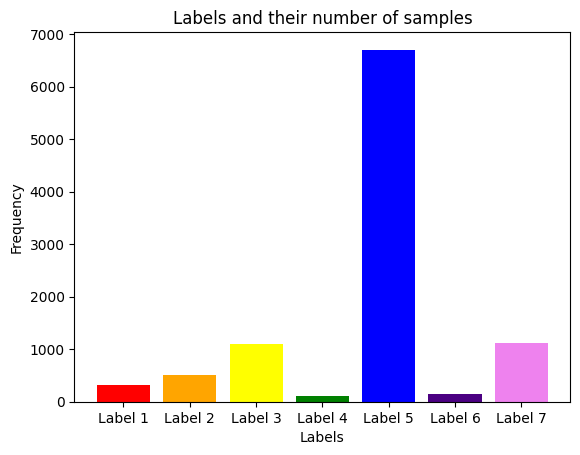

In [ ]:
def printDataBalance(Y):
    data = [0 for _ in range(7)]
    for i in Y:
        data[i] += 1

    # Colors for each bar
    colors = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'violet']

    # Create histogram
    plt.bar(range(len(data)), data, color=colors)

    # Adding labels and title
    plt.xlabel('Labels')
    plt.ylabel('Frequency')
    plt.title('Labels and their number of samples')

    # Customize x-axis ticks
    plt.xticks(range(len(data)), ['Label {}'.format(i+1) for i in range(len(data))])

printDataBalance(Y)

# Applying oversampling to features (X) and labels (Y): to balance the dataset

In [ ]:
oversample = RandomOverSampler(random_state=42)
X, Y  = oversample.fit_resample(X, Y)

X = X.to_numpy()
Y = Y.to_numpy()

# Dataset after resampling

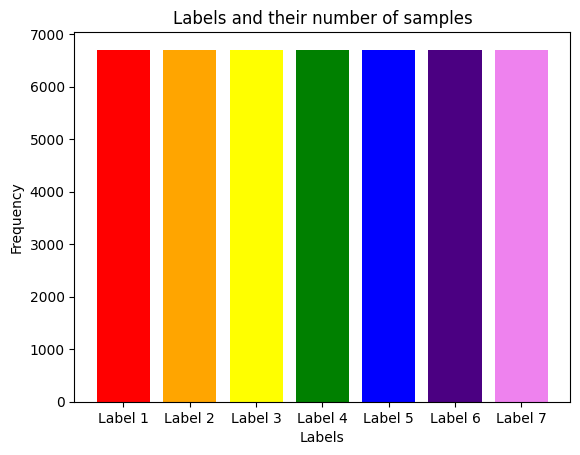

In [ ]:
printDataBalance(Y)

# Reshaping Dataset

In [ ]:
# Reshapes the features to have a 4D shape
# compatible with convolutional layers (height, width, channels)
# and normalizes the pixel values to be between 0 and 1.

Y = np.reshape(Y ,(46935,1))
X = np.reshape(X , (46935 , 28 , 28, 3))
Actual_X = X
Actual_Y = Y
# X = X/256

# Callbacks for Model

In [ ]:
# Callback to reducing the learning rate during training if
# monitored metric (val_accuracy in this case) does not improve.

learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy'
                                            , patience = 2
                                            , verbose=1
                                            ,factor=0.5
                                            , min_lr=0.00001)

early_stopping_callback = EarlyStopping(monitor='val_accuracy',  # Monitor validation accuracy
                                       patience=5,  # Number of epochs with no improvement after which training will be stopped
                                       restore_best_weights=True)  # Restore model weights from the epoch with the best value of the monitored quantity


# CNN Model

In [ ]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

def model_function():
    model = Sequential([
        # Convolutional layers with L2 regularization
        Convolution2D(32, (3, 3), activation='relu', input_shape=(28, 28, 3),
                      padding='same', kernel_regularizer=l2(0.01)),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        Convolution2D(64, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=l2(0.01)),
        Convolution2D(64, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=l2(0.01)),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        Convolution2D(128, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=l2(0.01)),
        Convolution2D(128, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=l2(0.01)),
        MaxPooling2D((2, 2)),
        # BatchNormalization(),
        # Convolution2D(256, (3, 3), activation='relu', padding='same',
        #               kernel_regularizer=l2(0.01)),
        # Convolution2D(256, (3, 3), activation='relu', padding='same',
        #               kernel_regularizer=l2(0.01)),
        # MaxPooling2D((2, 2)),
        # Flatten and dense layers
        Flatten(),
        Dropout(rate=0.5),
        Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        # Output layer
        Dense(7, activation='softmax')  # Assuming 7 classes
    ])

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Create the model
model = model_function()
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 14, 14, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 7, 7, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 7, 7, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 7)                   │             2

 Total params: 437,191 (1.67 MB)

 Trainable params: 436,551 (1.67 MB)

 Non-trainable params: 640 (2.50 KB)

# K-Fold Validation

Epoch 1/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.4239 - loss: 5.8503 - val_accuracy: 0.1761 - val_loss: 2.9362 - learning_rate: 0.0010
Epoch 2/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6863 - loss: 1.5523 - val_accuracy: 0.6132 - val_loss: 1.5474 - learning_rate: 0.0010
Epoch 3/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7337 - loss: 1.2195 - val_accuracy: 0.6230 - val_loss: 1.5244 - learning_rate: 0.0010
Epoch 4/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7639 - loss: 1.1277 - val_accuracy: 0.6862 - val_loss: 1.3778 - learning_rate: 0.0010
Epoch 5/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7880 - loss: 1.0369 - val_accuracy: 0.5046 - val_loss: 2.2263 - learning_rate: 0.0010
Epoch 6/20
581/587 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8053 - loss: 0.9856
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8053 - loss: 0.9855 -

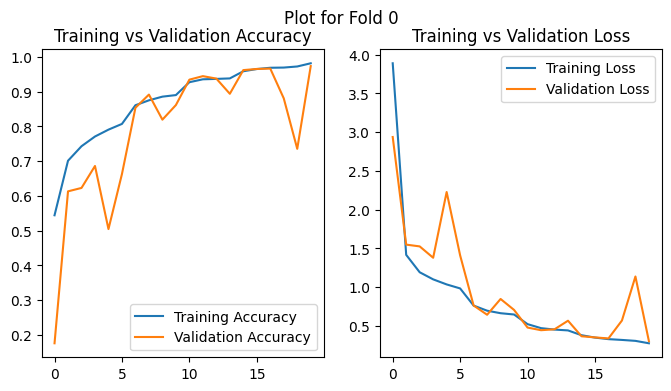

Epoch 1/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.3975 - loss: 5.7494 - val_accuracy: 0.1439 - val_loss: 3.4285 - learning_rate: 0.0010
Epoch 2/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6751 - loss: 1.5496 - val_accuracy: 0.1417 - val_loss: 12.6185 - learning_rate: 0.0010
Epoch 3/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7321 - loss: 1.2245 - val_accuracy: 0.2606 - val_loss: 4.3381 - learning_rate: 0.0010
Epoch 4/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7653 - loss: 1.1167 - val_accuracy: 0.1417 - val_loss: 48.4782 - learning_rate: 0.0010
Epoch 5/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7830 - loss: 1.0665 - val_accuracy: 0.4432 - val_loss: 2.9792 - learning_rate: 0.0010
Epoch 6/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8046 - loss: 0.9852 - val_accuracy: 0.1402 - val_loss: 5.6703 - learning_rate: 0.0010
Epoch 7/20
582/587 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8212 - loss: 0.91

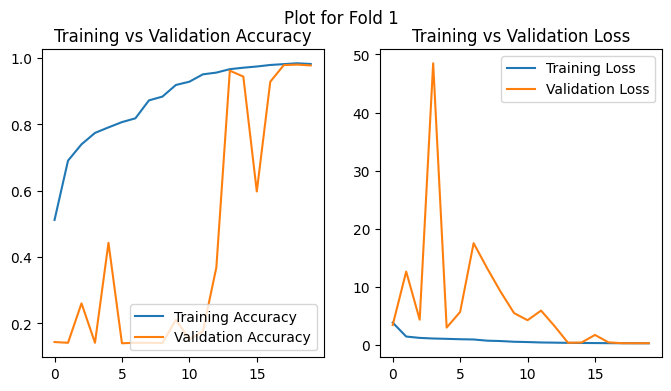

Epoch 1/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.3998 - loss: 5.8086 - val_accuracy: 0.2271 - val_loss: 2.9920 - learning_rate: 0.0010
Epoch 2/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6775 - loss: 1.5399 - val_accuracy: 0.1371 - val_loss: 9.2998 - learning_rate: 0.0010
Epoch 3/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7437 - loss: 1.1924 - val_accuracy: 0.4757 - val_loss: 2.0744 - learning_rate: 0.0010
Epoch 4/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7722 - loss: 1.0943 - val_accuracy: 0.7751 - val_loss: 1.0379 - learning_rate: 0.0010
Epoch 5/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7935 - loss: 1.0060 - val_accuracy: 0.7113 - val_loss: 1.2665 - learning_rate: 0.0010
Epoch 6/20
584/587 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8145 - loss: 0.9421
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8145 - loss: 0.9421 -

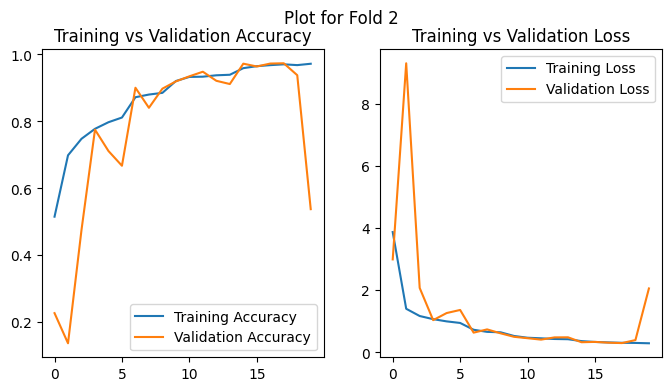

Epoch 1/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.4120 - loss: 5.6736 - val_accuracy: 0.1581 - val_loss: 3.4147 - learning_rate: 0.0010
Epoch 2/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6892 - loss: 1.5009 - val_accuracy: 0.5578 - val_loss: 1.8251 - learning_rate: 0.0010
Epoch 3/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7373 - loss: 1.1880 - val_accuracy: 0.6551 - val_loss: 1.4583 - learning_rate: 0.0010
Epoch 4/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7653 - loss: 1.0918 - val_accuracy: 0.5529 - val_loss: 1.8790 - learning_rate: 0.0010
Epoch 5/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7931 - loss: 1.0187 - val_accuracy: 0.7862 - val_loss: 1.0208 - learning_rate: 0.0010
Epoch 6/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8078 - loss: 0.9709 - val_accuracy: 0.7940 - val_loss: 0.9684 - learning_rate: 0.0010
Epoch 7/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8145 - loss: 0.9315

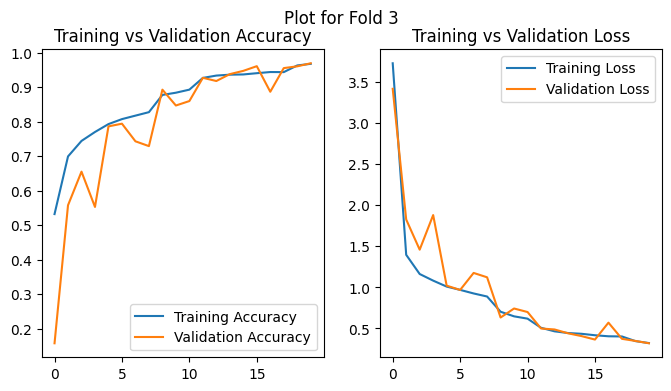

Epoch 1/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.4211 - loss: 5.6709 - val_accuracy: 0.2152 - val_loss: 2.9433 - learning_rate: 0.0010
Epoch 2/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6913 - loss: 1.4779 - val_accuracy: 0.4004 - val_loss: 2.4813 - learning_rate: 0.0010
Epoch 3/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7365 - loss: 1.1965 - val_accuracy: 0.6852 - val_loss: 1.3282 - learning_rate: 0.0010
Epoch 4/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7612 - loss: 1.1026 - val_accuracy: 0.5674 - val_loss: 1.6585 - learning_rate: 0.0010
Epoch 5/20
583/587 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7869 - loss: 1.0339
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7870 - loss: 1.0338 - val_accuracy: 0.5144 - val_loss: 1.9222 - learning_rate: 0.0010
Epoch 6/20
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8472 - loss: 0.8382 -

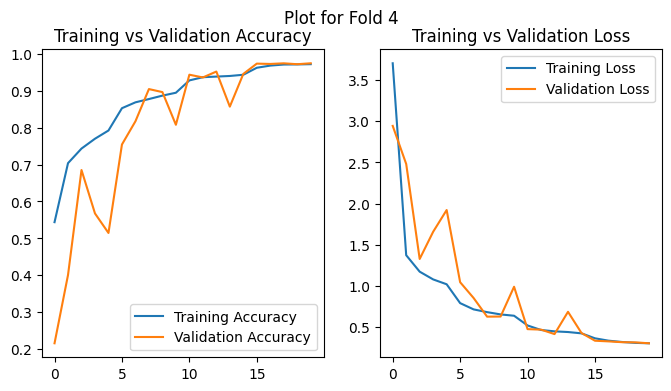

In [ ]:
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
i = 0

for train_index, test_index in kfold.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = Y[train_index], Y[test_index]

    model = model_function()

    # Train the model
    fitting_stats = model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=64,
        validation_data=(X_test, y_test),
        callbacks=[learning_rate_reduction]
    )

    # Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test)
    print(f"Test Accuracy: {accuracy}")

    # Extract training and validation metrics
    acc = fitting_stats.history['accuracy']
    val_acc = fitting_stats.history['val_accuracy']
    loss = fitting_stats.history['loss']
    val_loss = fitting_stats.history['val_loss']

    # Dynamically determine the epoch count
    epochs = range(len(acc))  # Length of the accuracy list

    # Plot accuracy
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Training Accuracy")
    plt.plot(epochs, val_acc, label="Validation Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend(loc="lower right")

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Training Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.title("Training vs Validation Loss")
    plt.legend(loc="upper right")

    plt.suptitle('Plot for Fold ' + str(i))
    plt.show()

    i += 1
